In [67]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OrdinalEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
import json

In [2]:
df = pd.read_csv("youtube_videos.csv")

In [3]:
df.head()

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,shares,watch_time_minutes,avg_view_duration_seconds,click_through_rate,channel_age_years,subscribers,tags_count,hashtags
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,1193,1091087,287,0.0100,1.3,441016,18.0,"[""ai"", ""tutorial"", ""trending""]"
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,183,423818,1014,0.0230,0.8,25339,17.0,"[""tutorial""]"
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,16119,12952634,587,0.1022,4.8,2398429,NaN,"[""explained""]"
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,1797,2018334,645,0.0413,3.9,498144,13.0,"[""gaming"", ""trending"", ""explained"", ""tech""]"
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,30,262565,1252,0.0100,1.3,30039,10.0,"[""explained"", ""shorts""]"


In [11]:
minmax_scaler = MinMaxScaler()
df["subscribers_minmax"] = minmax_scaler.fit_transform(
    df[["subscribers"]]
)

In [12]:
df["subscribers_minmax"].describe()

,subscribers_minmax
count,210.000000
mean,0.128853
std,0.265999
min,0.000000
25%,0.002555
50%,0.016794
75%,0.061946
max,1.000000


In [9]:
standard_Scaler = StandardScaler()
df["views_zscore"] = standard_Scaler.fit_transform(df[["views"]])

In [10]:
df[["views", "views_zscore"]].describe()

,views,views_zscore
count,2.100000e+02,2.100000e+02
mean,5.485440e+05,2.537653e-17
std,1.223751e+06,1.002389e+00
min,1.412000e+03,-4.481625e-01
25%,1.080400e+04,-4.404694e-01
50%,6.597350e+04,-3.952794e-01
75%,3.108772e+05,-1.946757e-01
max,7.038551e+06,5.316044e+00


In [14]:
robust_scaler = RobustScaler()
df["views_robust"] = robust_scaler.fit_transform(df[["views"]])

In [15]:
df[["views", "views_robust"]].describe()

,views,views_robust
count,2.100000e+02,210.000000
mean,5.485440e+05,1.608176
std,1.223751e+06,4.078175
min,1.412000e+03,-0.215152
25%,1.080400e+04,-0.183853
50%,6.597350e+04,0.000000
75%,3.108772e+05,0.816147
max,7.038551e+06,23.236251




---


Participation for minmax, robust, and standard scaling
with other columns

In [18]:
#Minmax
df["comments_minmax"] = minmax_scaler.fit_transform(
    df[["comments"]]
)
df["comments_minmax"].describe()

,comments_minmax
count,210.000000
mean,0.054907
std,0.128226
min,0.000000
25%,0.000854
50%,0.004042
75%,0.030860
max,1.000000


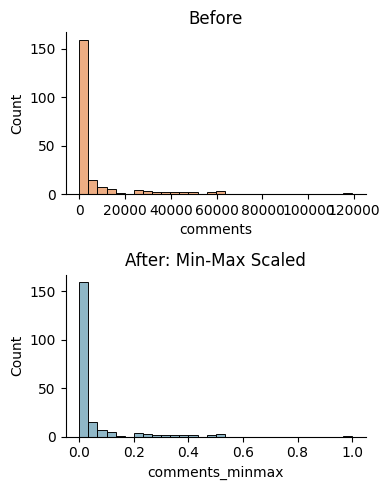

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["comments"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before")
axes[0].set_xlabel("comments")

sns.histplot(df["comments_minmax"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: Min-Max Scaled")
axes[1].set_xlabel("comments_minmax")

sns.despine()
plt.tight_layout()
plt.show()

In [23]:
#Robust
df["likes_robust"] = robust_scaler.fit_transform(df[["likes"]])
df[["likes", "likes_robust"]].describe()

,likes,likes_robust
count,210.000000,210.000000
mean,25765.304762,1.959849
std,66234.880530,5.509473
min,33.000000,-0.180586
25%,488.750000,-0.142676
50%,2204.000000,0.000000
75%,12510.750000,0.857324
max,455256.000000,37.685244


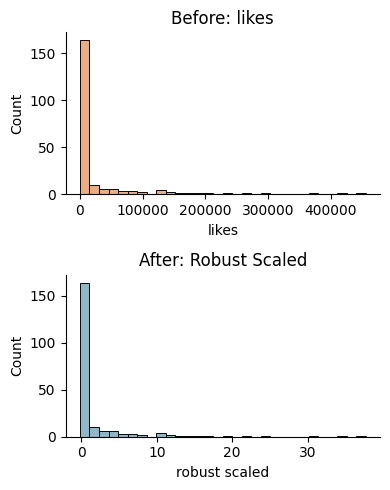

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["likes"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: likes")
axes[0].set_xlabel("likes")

sns.histplot(df["likes_robust"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: Robust Scaled")
axes[1].set_xlabel("robust scaled")

sns.despine()
plt.tight_layout()
plt.show()

In [21]:
#Standard
df["watch_time_minutes_zscore"] = standard_Scaler.fit_transform(df[["watch_time_minutes"]])
df[["watch_time_minutes", "watch_time_minutes_zscore"]].describe()

,watch_time_minutes,watch_time_minutes_zscore
count,2.100000e+02,210.000000
mean,1.461476e+07,0.000000
std,6.595676e+07,1.002389
min,2.494000e+03,-0.222072
25%,1.399760e+05,-0.219983
50%,6.607500e+05,-0.212068
75%,3.844212e+06,-0.163687
max,7.376597e+08,10.988603


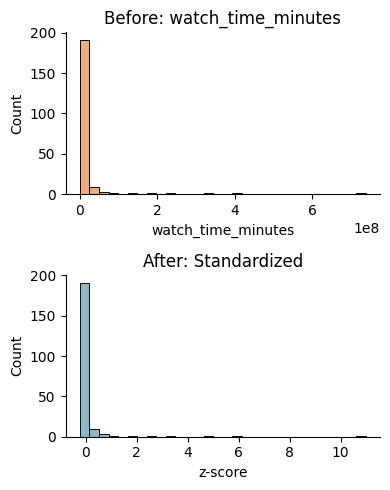

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["watch_time_minutes"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: watch_time_minutes")
axes[0].set_xlabel("watch_time_minutes")

sns.histplot(df["watch_time_minutes_zscore"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: Standardized")
axes[1].set_xlabel("z-score")

sns.despine()
plt.tight_layout()
plt.show()



---

Log

In [27]:
df["log_views"] = np.log1p(df["views"])
df[["views", "log_views"]].describe()

,views,log_views
count,2.100000e+02,210.000000
mean,5.485440e+05,11.146775
std,1.223751e+06,2.175266
min,1.412000e+03,7.253470
25%,1.080400e+04,9.287764
50%,6.597350e+04,11.096972
75%,3.108772e+05,12.645811
max,7.038551e+06,15.766913


<Axes: xlabel='views', ylabel='Count'>

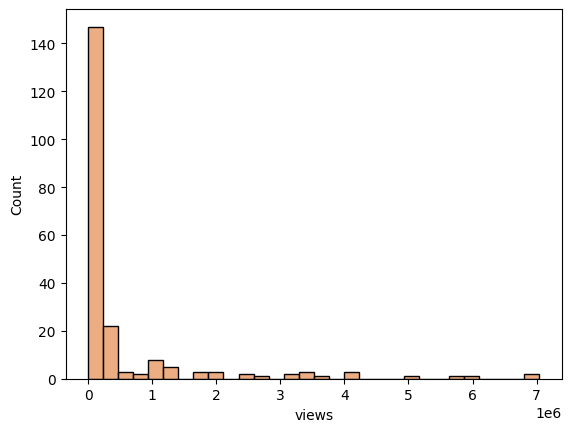

In [29]:
sns.histplot(df["views"], color="#e8925a", bins=30)

<Axes: xlabel='log_views', ylabel='Count'>

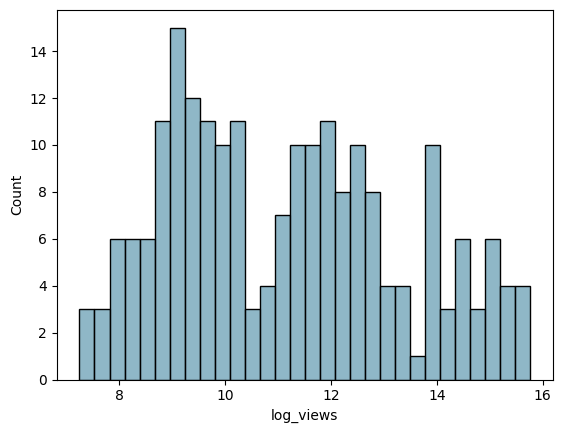

In [30]:
sns.histplot(df["log_views"], color="#6a9fb5", bins=30)

In [31]:
df["log_watch_time_minutes"] = np.log1p(df["watch_time_minutes"])
df[["watch_time_minutes", "log_watch_time_minutes"]].describe()

,watch_time_minutes,log_watch_time_minutes
count,2.100000e+02,210.000000
mean,1.461476e+07,13.613885
std,6.595676e+07,2.388423
min,2.494000e+03,7.822044
25%,1.399760e+05,11.848957
50%,6.607500e+05,13.401126
75%,3.844212e+06,15.162023
max,7.376597e+08,20.418993


<Axes: xlabel='watch_time_minutes', ylabel='Count'>

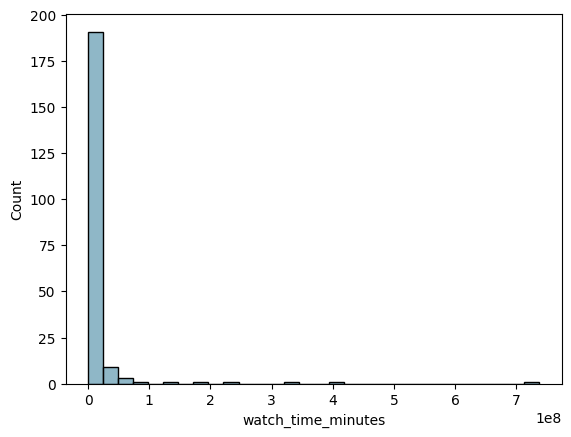

In [33]:
sns.histplot(df["watch_time_minutes"], color="#6a9fb5", bins=30)

<Axes: xlabel='log_watch_time_minutes', ylabel='Count'>

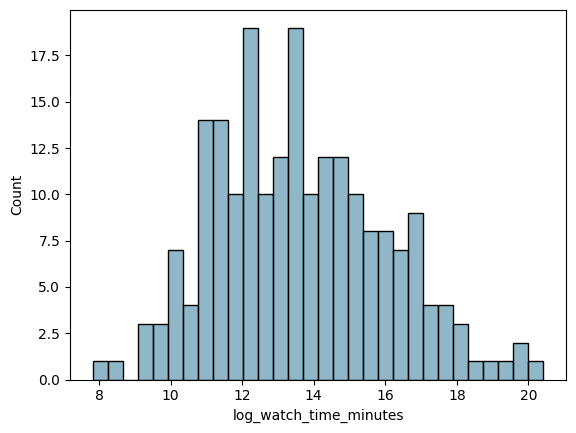

In [32]:
sns.histplot(df["log_watch_time_minutes"], color="#6a9fb5", bins=30)



---

Binning

In [34]:
bins = [0, 300, 1800, float("inf")]
labels = ["short", "medium", "long"]

df["duration_bin"] = pd.cut(
    df["duration_seconds"],
    bins=bins,
    labels=labels
)

<Axes: xlabel='duration_bin', ylabel='count'>

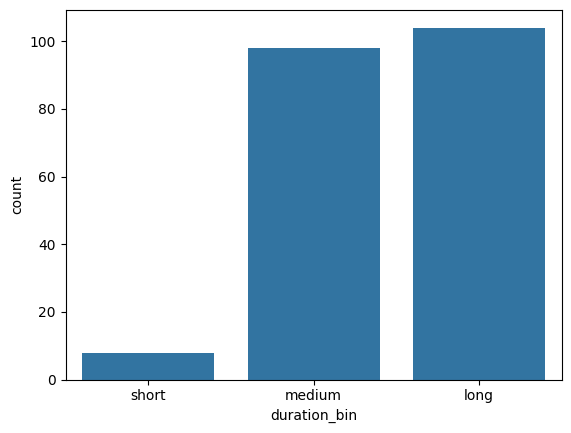

In [35]:
sns.countplot(x="duration_bin", data=df)

Participation

In [36]:
df["likes"].describe()

,likes
count,210.000000
mean,25765.304762
std,66234.880530
min,33.000000
25%,488.750000
50%,2204.000000
75%,12510.750000
max,455256.000000


In [42]:
likes_bins = [0, 500, 12600, float("inf")]
likes_labels = ["low", "medium", "high"]

df["likes_bin"] = pd.cut(
    df["likes"],
    bins=likes_bins,
    labels=likes_labels
)

<Axes: xlabel='likes_bin', ylabel='count'>

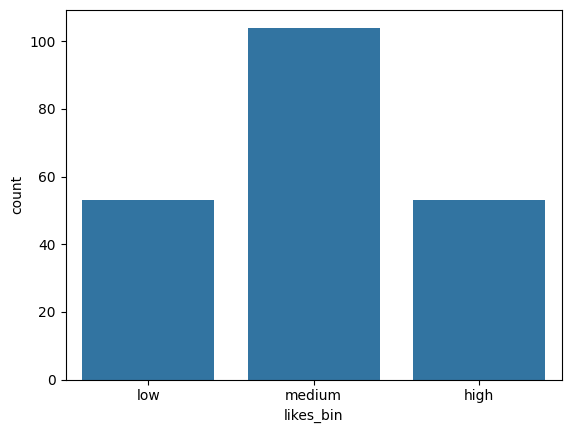

In [43]:
sns.countplot(x="likes_bin", data=df)



---

Ordinal encoding

In [45]:
df["channel_tier"].unique()

array(['Mid', 'Small', 'Large'], dtype=object)

In [49]:
enc = OrdinalEncoder(categories=[["Small", "Mid", "Large"]])
df["channel_tier_encoded"] = enc.fit_transform(
    df[["channel_tier"]]
)
df[["channel_tier", "channel_tier_encoded"]]

,channel_tier,channel_tier_encoded
0,Mid,1.0
1,Small,0.0
2,Large,2.0
3,Mid,1.0
4,Small,0.0
...,...,...
205,Small,0.0
206,Small,0.0
207,Mid,1.0
208,Small,0.0




---

One hot encoding

In [50]:
ohe = pd.get_dummies(df["category"], prefix="is")

In [52]:
ohe

,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,False,False,False,True,False,False
1,False,False,True,False,False,False
2,False,False,True,False,False,False
3,False,False,True,False,False,False
4,False,False,False,True,False,False
...,...,...,...,...,...,...
205,False,True,False,False,False,False
206,False,False,False,False,True,False
207,False,False,True,False,False,False
208,True,False,False,False,False,False


In [53]:
result = pd.concat([df[["video_id", "category"]], ohe], axis=1)

print(result.head(6).to_string(index=False))

video_id category  is_Comedy  is_Education  is_Gaming  is_Music  is_News  is_Vlog
vid_0000    Music      False         False      False      True    False    False
vid_0001   Gaming      False         False       True     False    False    False
vid_0002   Gaming      False         False       True     False    False    False
vid_0003   Gaming      False         False       True     False    False    False
vid_0004    Music      False         False      False      True    False    False
vid_0005     News      False         False      False     False     True    False




---

Time / Date

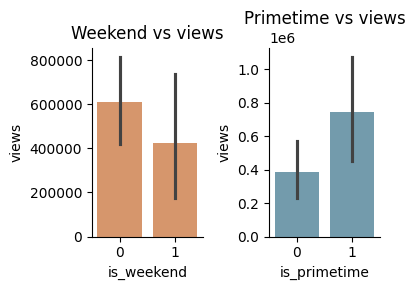

In [54]:
# simulate a full timestamp from existing day/hour columns
day_map = {
    "Monday": 0, "Tuesday": 1, "Wednesday": 2,
    "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6
}
rng = np.random.default_rng(42)
base = pd.Timestamp("2024-01-01")

df["uploaded_at"] = [
    base
    + pd.offsets.Week(weekday=day_map[d])
    + pd.Timedelta(hours=int(h))
    + pd.Timedelta(minutes=int(rng.integers(0, 60)))
    for d, h in zip(df["upload_day"], df["upload_hour"])
]

# extract features from timestamp
df["is_weekend"] = (df["uploaded_at"].dt.dayofweek >= 5).astype(int)
df["is_primetime"] = (
    (df["uploaded_at"].dt.hour >= 18) &
    (df["uploaded_at"].dt.hour <= 22)
).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(4, 3))

sns.barplot(data=df,
            x="is_weekend",
            y="views",
            color="#e8925a",
            ax=axes[0])
axes[0].set_title("Weekend vs views")
axes[0].set_xlabel("is_weekend")

sns.barplot(data=df,
            x="is_primetime",
            y="views",
            color="#6a9fb5",
            ax=axes[1])
axes[1].set_title("Primetime vs views")
axes[1].set_xlabel("is_primetime")

sns.despine()
plt.tight_layout()
plt.show()



---

Text

In [55]:
def countCaps(t):
  sum = 0
  words = t.split()
  for word in words:
    if word.isupper():
      sum += 1
  return sum

In [56]:
df["caps_count"] = df["title"].apply(
    # lambda t: sum(1 for w in t.split() if w.isupper())
    countCaps
)

In [57]:
df["caps_count"]

,caps_count
0,3
1,1
2,0
3,0
4,4
...,...
205,3
206,2
207,0
208,2




---

TF-IDF

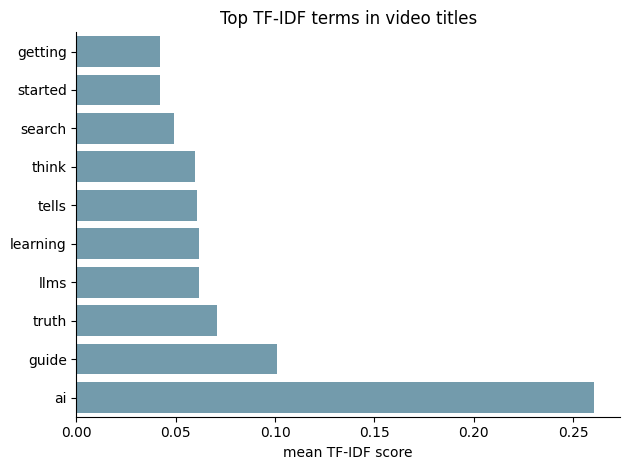

In [64]:
vectorizer = TfidfVectorizer(max_features=10, stop_words="english")
tfidf_matrix = vectorizer.fit_transform(df["title"])

terms = vectorizer.get_feature_names_out()
mean_scores = tfidf_matrix.toarray().mean(axis=0)

tfidf_df = pd.DataFrame({
    "term": terms,
    "mean_tfidf": mean_scores
}).sort_values("mean_tfidf", ascending=True)

sns.barplot(data=tfidf_df,
            x="mean_tfidf",
            y="term",
            color="#6a9fb5")

plt.title("Top TF-IDF terms in video titles")
plt.xlabel("mean TF-IDF score")
plt.ylabel("")
sns.despine()
plt.tight_layout()
plt.show()


---
ratio


In [58]:
df["duration_minutes"] = df["duration_seconds"] / 60
df["retention_rate"] = df["watch_time_minutes"] / (df["views"]*df["duration_minutes"])

In [59]:
df["retention_rate"]

,retention_rate
0,0.398058
1,0.535375
2,0.415428
3,0.483146
4,0.396453
...,...
205,0.469772
206,0.289126
207,0.495605
208,0.528993




---

Interaction feature

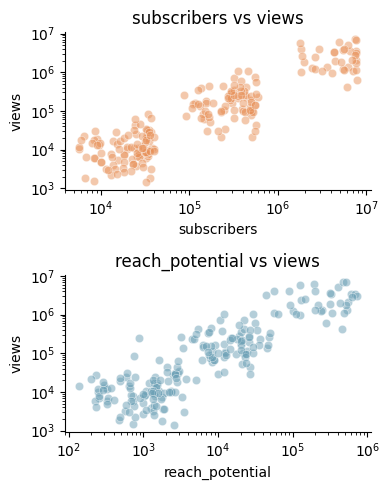

In [65]:
df["reach_potential"] = (
    df["subscribers"] * df["click_through_rate"]
)

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.scatterplot(data=df,
                x="subscribers",
                y="views",
                color="#e8925a",
                alpha=0.5,
                ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("subscribers vs views")

sns.scatterplot(data=df,
                x="reach_potential",
                y="views",
                color="#6a9fb5",
                alpha=0.5,
                ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("reach_potential vs views")

sns.despine()
plt.tight_layout()
plt.show()

In [68]:
df["hashtags"] = df["hashtags"].apply(json.loads)

from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
hashtag_encoded = pd.DataFrame(
    mlb.fit_transform(df["hashtags"]),
    columns=mlb.classes_,
    index=df.index
)

result = pd.concat([df[["video_id"]], hashtag_encoded], axis=1)
print(result.head(4).to_string(index=False))

video_id  ai  chatgpt  comedy  datascience  deeplearning  explained  gaming  howto  llm  machinelearning  music  news  python  review  shorts  tech  trending  tutorial  viral  vlog
vid_0000   1        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         1         1      0     0
vid_0001   0        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         0         1      0     0
vid_0002   0        0       0            0             0          1       0      0    0                0      0     0       0       0       0     0         0         0      0     0
vid_0003   0        0       0            0             0          1       1      0    0                0      0     0       0       0       0     1         1         0      0     0
